In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from trebl_tools import pipelines, finder, umi_deduplicate
import glob
import tqdm
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
pipeline = pipelines.TreblPipeline(
    db_path = "../../../duckdb/ChopTFs_pipeline.db",  
    design_file_path = "/global/scratch/projects/fc_mvslab/OpenProjects/Marissa/DesignFiles/Gcn4_Design.csv",
    error_correction = False,   
    output_path = "../../../output/ChopTFs_pipeline"
)

# What sequences to search for?
AD_end = finder.Barcode(name="AD_end", preceder="", post="TGACTAG", length=40)
AD_BC = finder.Barcode(name="AD_BC", preceder="CGCGCC", post="GGGCCC", length=11)
RPTR_BC = finder.Barcode(name="RPTR_BC", preceder="CTCGAG", post="GGCCGC", length=14)

AD_UMI = finder.Barcode(name = "UMI", preceder = "TGATTT", post = "", length = 12)
RT_UMI = finder.Barcode(name = "UMI", preceder = "TGTCAC", post = "", length = 12)

AD_bc_objects = [AD_end, AD_BC]
RT_bc_objects = [RPTR_BC]

# Reads loss

registering temp step1
Join condition (all bc_objects): m.AD_end = s.AD_end AND m.AD_BC = s.AD_BC


100%|██████████| 30/30 [01:27<00:00,  2.90s/it]


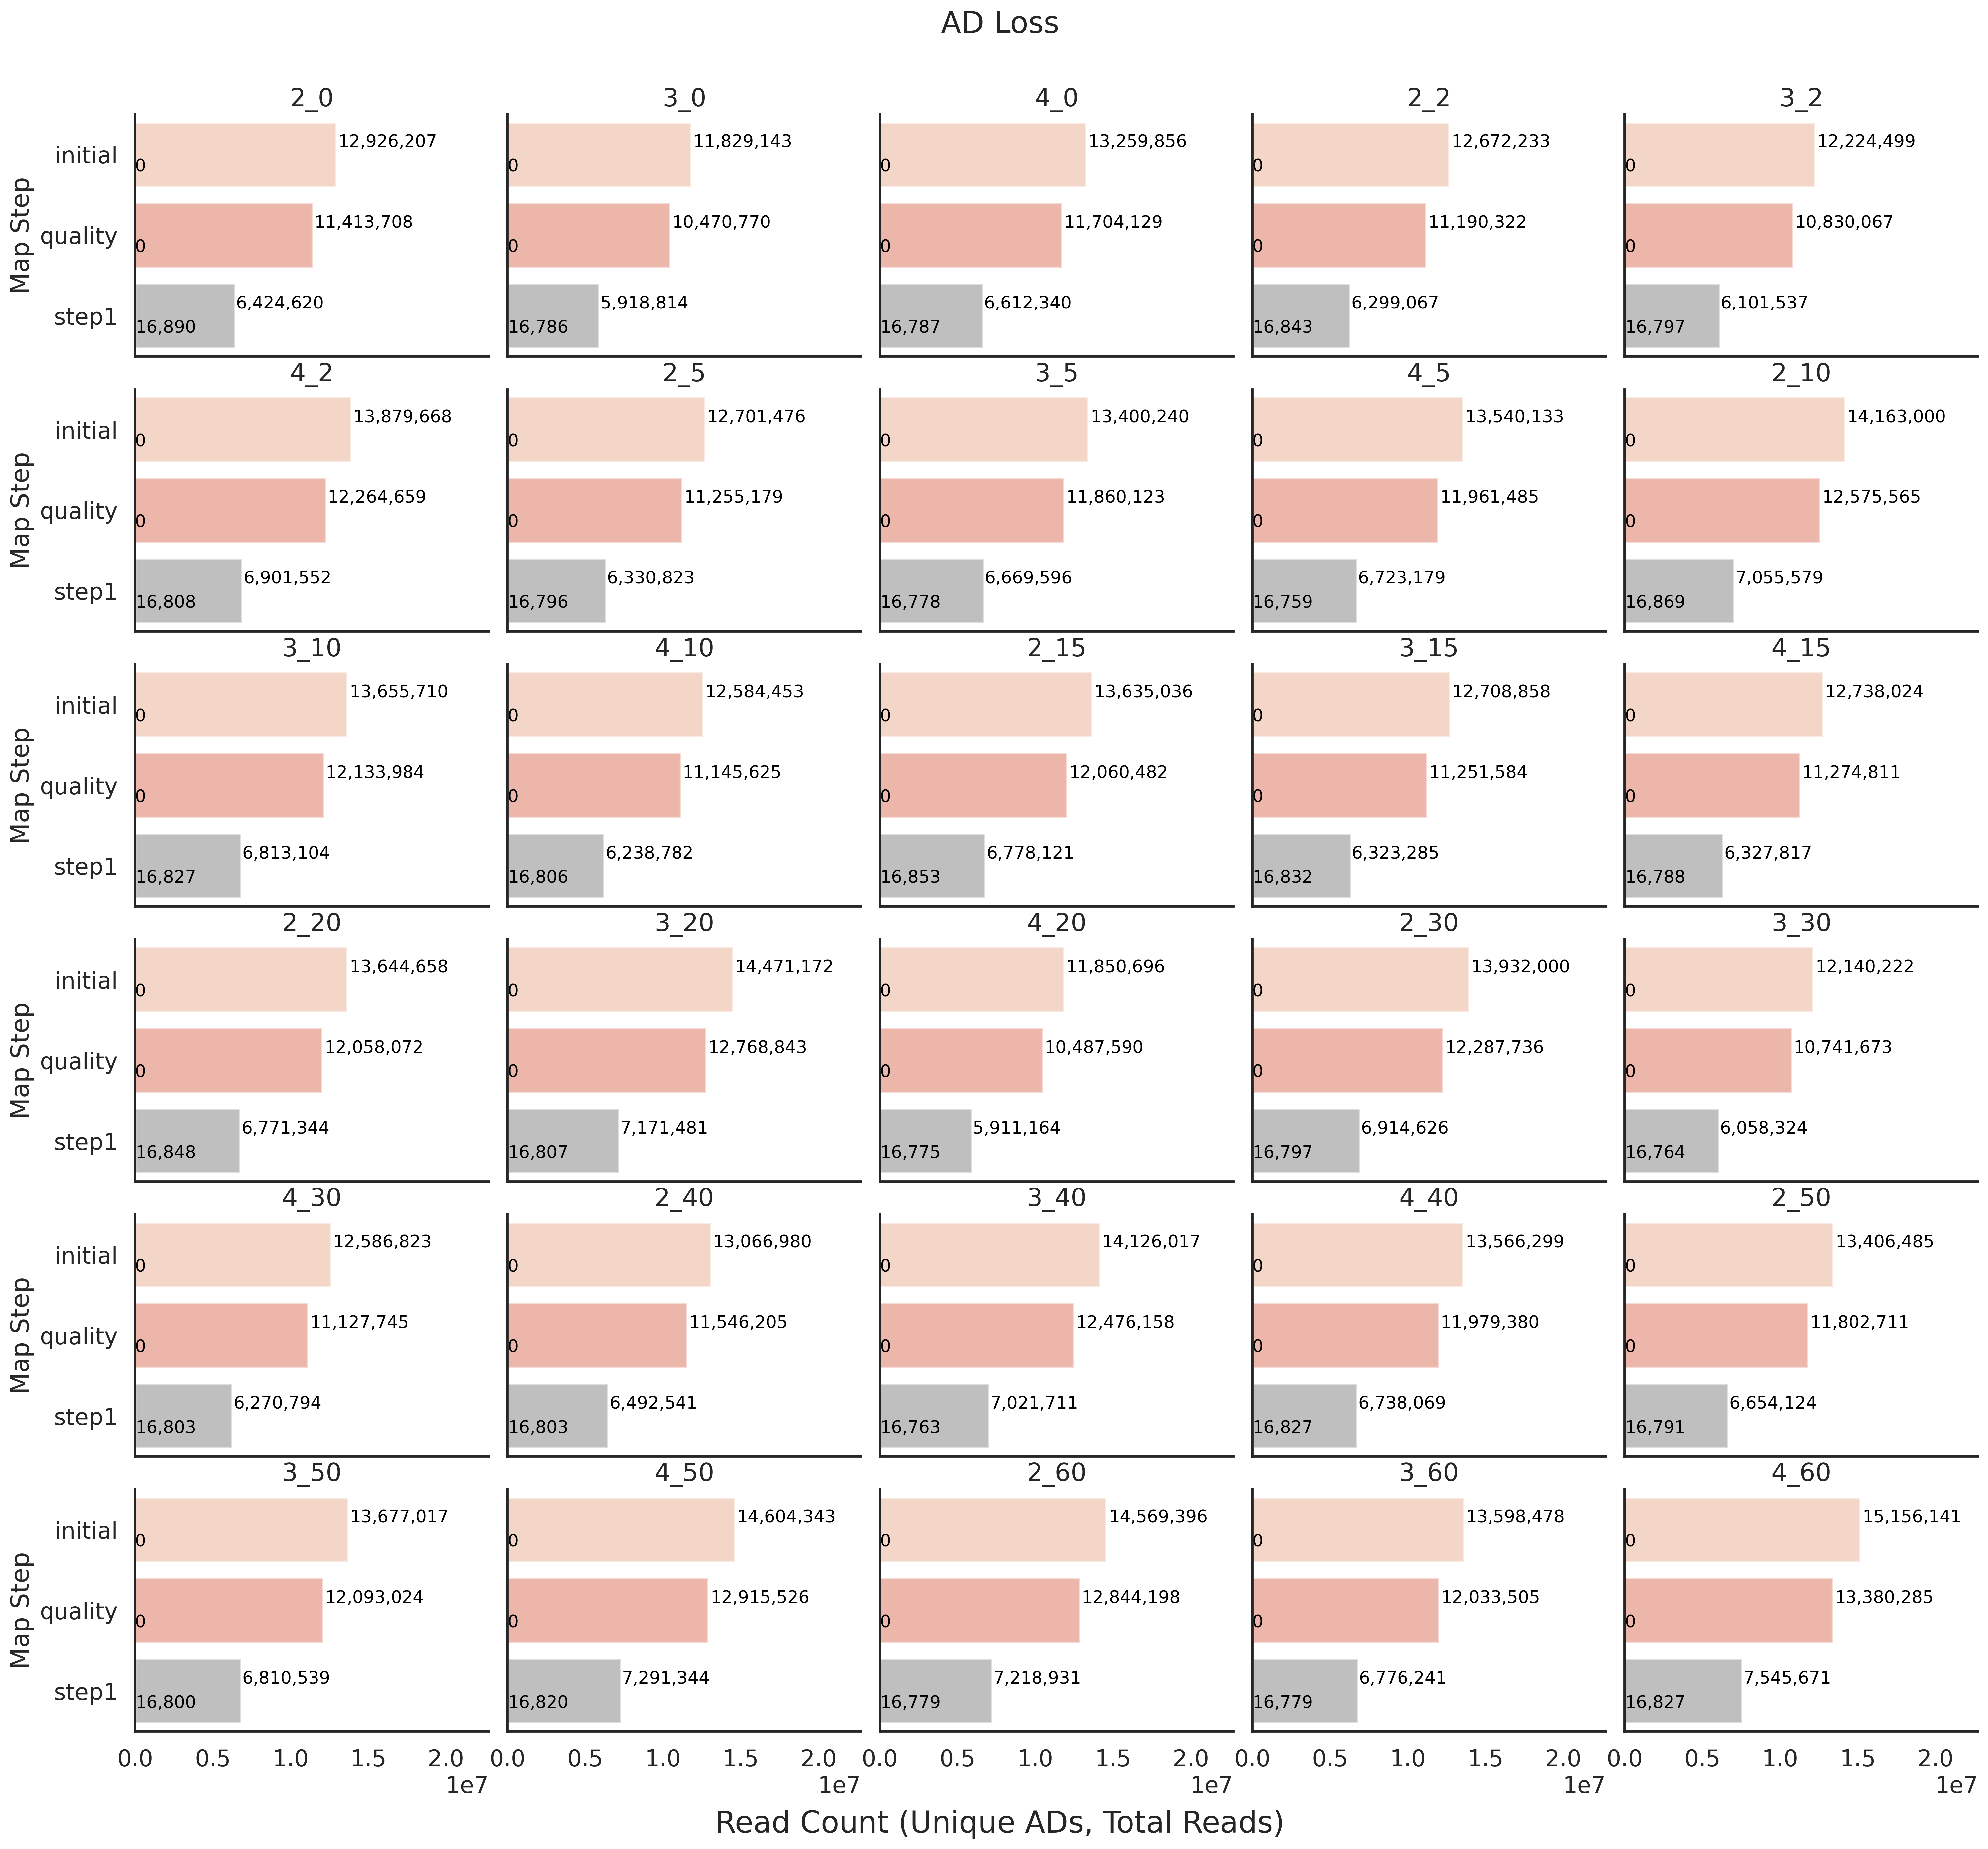

In [16]:
pipeline.new_plot_trebl_experiment_loss(AD_bc_objects, 
                                        "../../../output/ChopTFs_pipeline/step1.csv", 
                                        "trebl_experiment_",
                                        table_type = "AD",
                                        rep_regex="AD_(\d+)",
                                        time_regex="AD_\d+_(\d+)")

registering temp step1
Join condition (all bc_objects): m.RPTR_BC = s.RPTR_BC


100%|██████████| 30/30 [01:23<00:00,  2.79s/it]


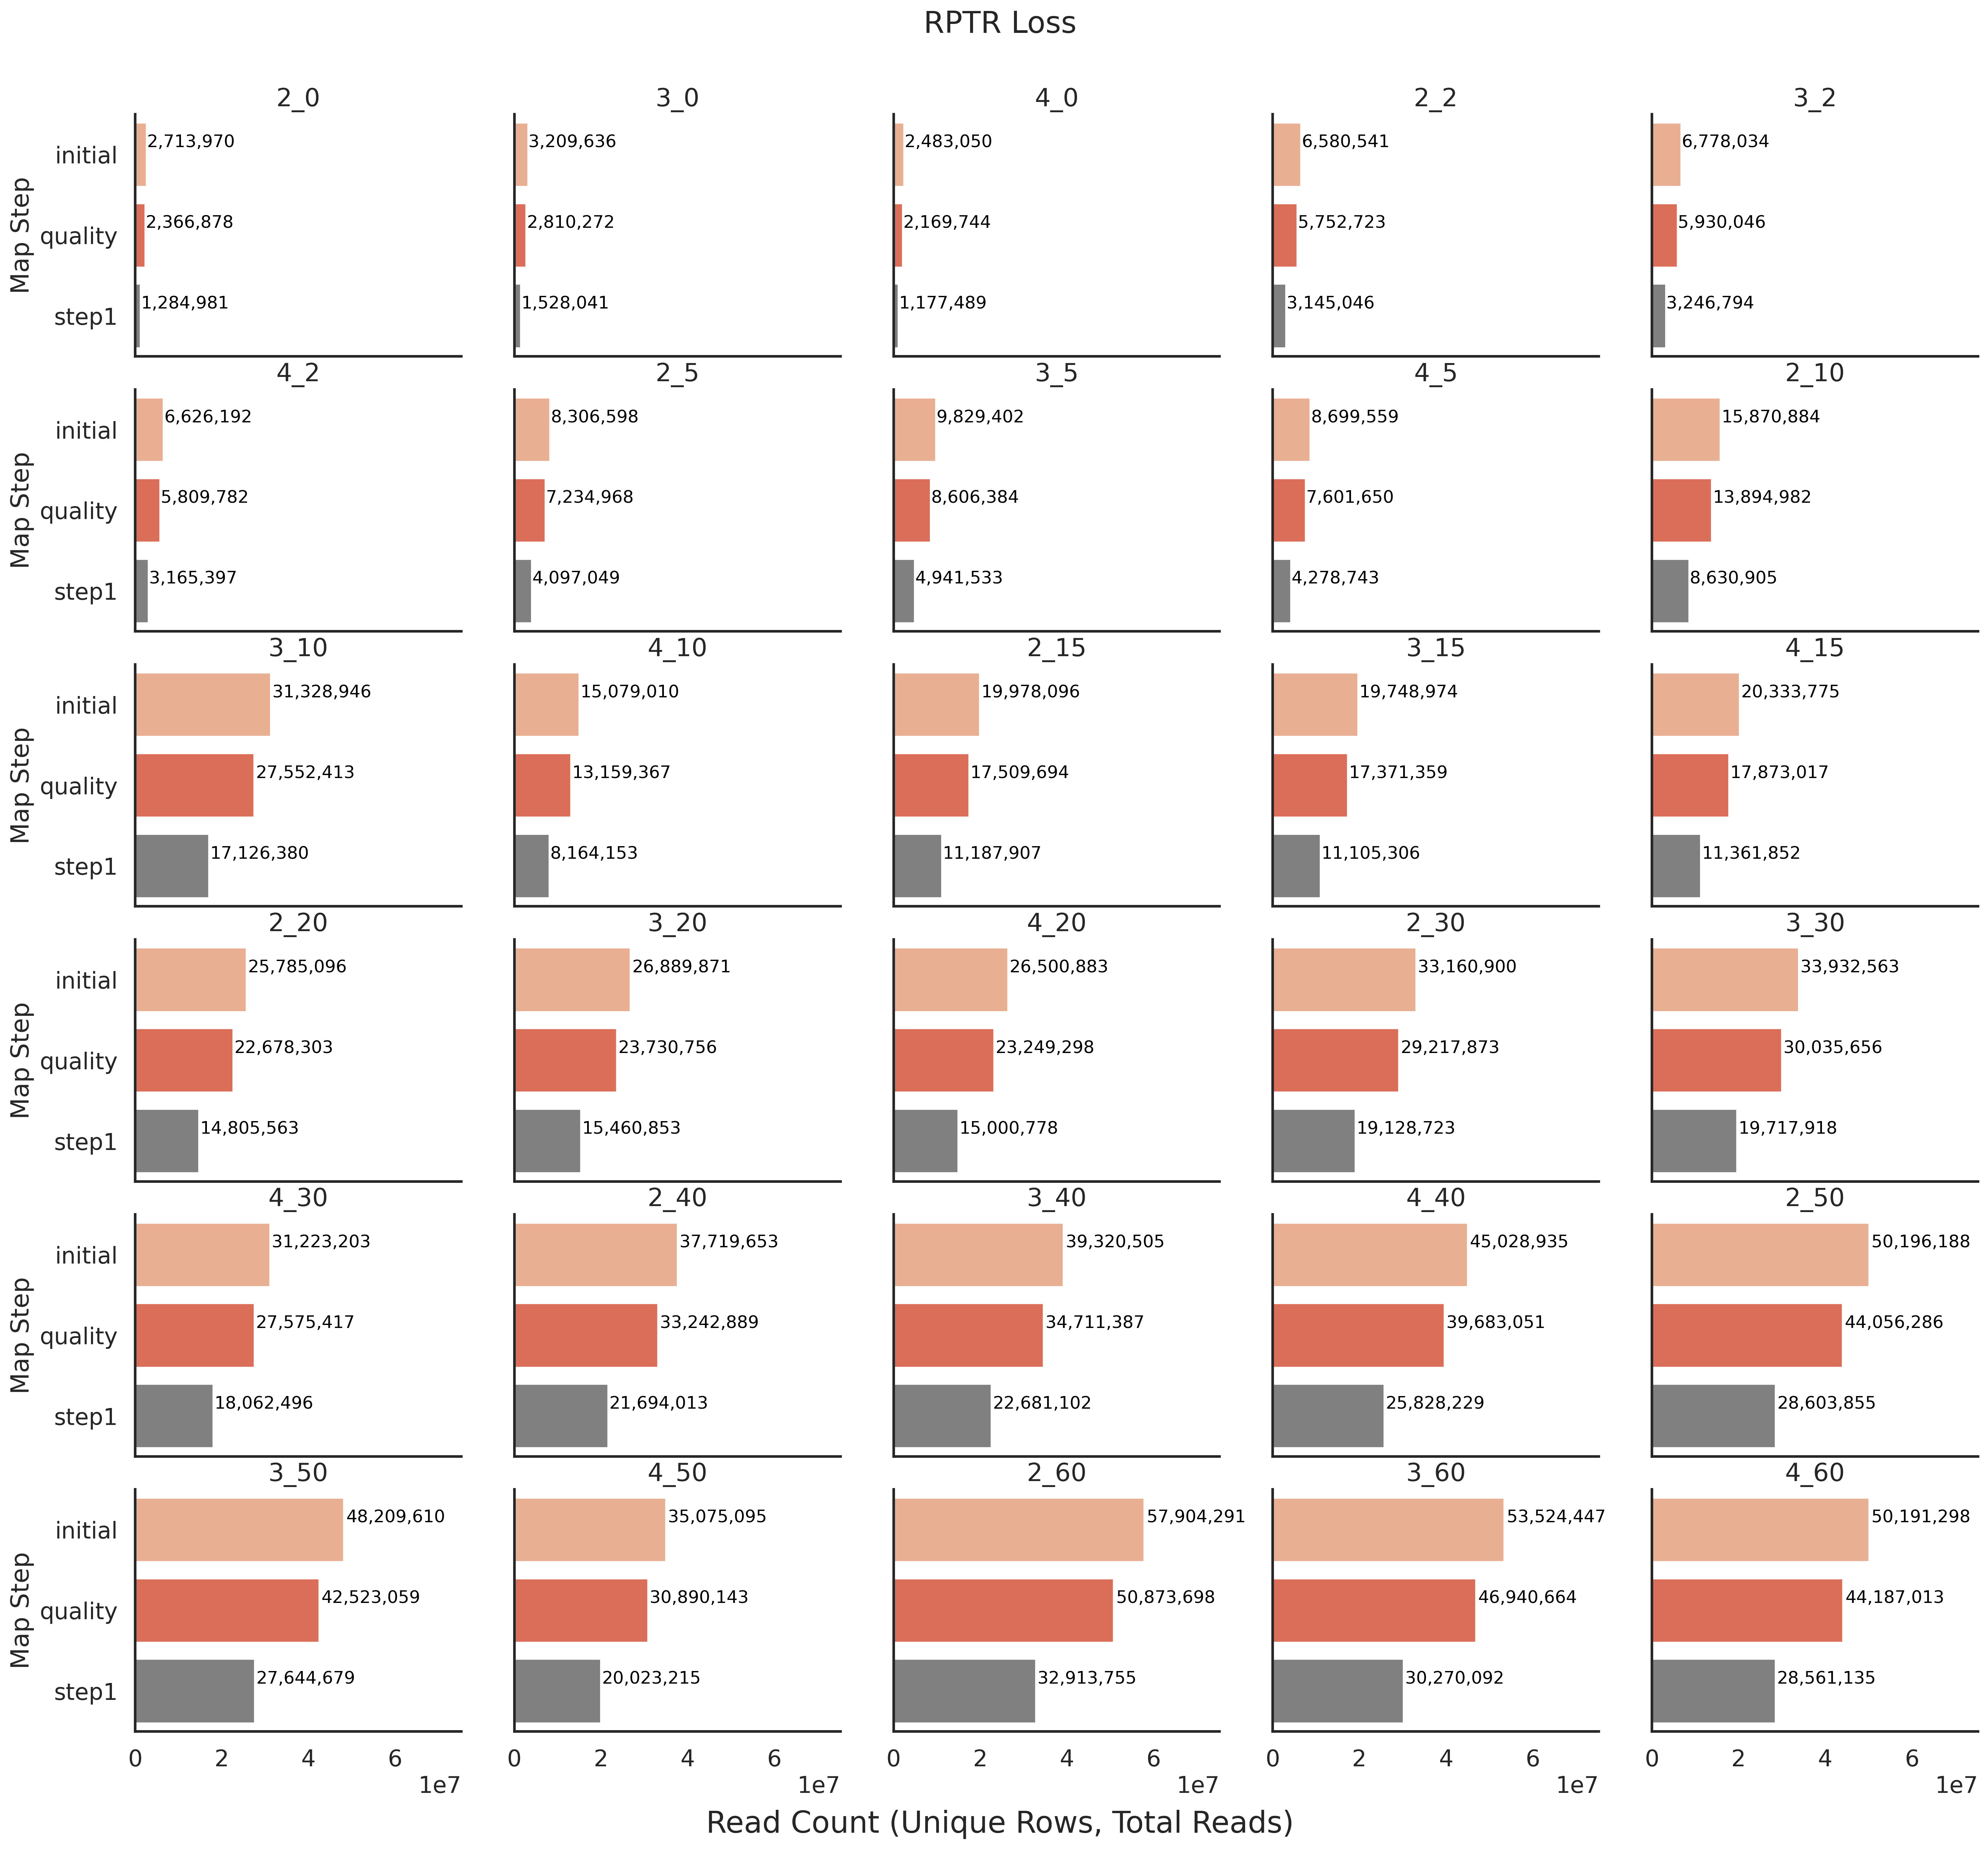

In [20]:
pipeline.new_plot_trebl_experiment_loss(RT_bc_objects, 
                                        "../../../output/ChopTFs_pipeline/step1.csv", 
                                        "trebl_experiment_",
                                        table_type = "RPTR",
                                        rep_regex="RP_(\d+)",
                                        time_regex="RP_\d+_(\d+)")

# How many unique barcodes remain?

In [10]:
def read_and_label(files, label):
    """
    Reads TSV files, adds a descriptive 'file_base' column.

    Parameters:
        files: list of file paths
        label: string, e.g., "AD_simple" or "RPTR_directional"

    Returns:
        DataFrame with added 'file_base' column
    """
    dfs = []
    for f in tqdm.tqdm(files):
        df = pd.read_csv(f, sep="\t")
        # descriptive file_base: <label>_<original_file_name_without_ext>
        df["file_base"] = f"{label}_{os.path.splitext(os.path.basename(f))[0]}"
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

In [11]:
# Find simple and directional AD files
simple_AD_files = glob.glob("../../../output/ChopTFs_pipeline/trebl_experiment_/*AD*/*simple*")
# Read files with descriptive file_base
simple_AD_df = read_and_label(simple_AD_files, label="AD_simple")

100%|██████████| 30/30 [00:14<00:00,  2.05it/s]


In [12]:
simple_AD_df["gene"] = simple_AD_df["AD_end"] + simple_AD_df["AD_BC"]
simple_AD_df["rep"] = simple_AD_df["file_base"].str.extract(r'AD_(\d+)_').astype(int)
simple_AD_df["time"] = simple_AD_df["file_base"].str.extract(r'AD_\d+_(\d+)').astype(int)
simple_AD_df

,AD_end,AD_BC,count,file_base,gene,rep,time
0,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCA,GGCAAAACTCT,22224,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGTCTTCTTCATTTACTTTGGTTGCTAATAATCCACTCCAGGCAAA...,4,50
1,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAA,CAGTTTAGCTA,18886,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAACAGTTT...,4,50
2,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACT,TGTCCTTGTCG,16525,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACTTGTCCT...,4,50
3,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTT,GCCATATAGGT,15934,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TGGAGAATAAACAAACTGGTTTGGTCTTGGATTCTATGTTGCCATA...,4,50
4,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCA,CTCACCTGCCC,13390,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCACTCACC...,4,50
...,...,...,...,...,...,...,...
9978655,TAAATATTCTATCTTGCAAACGAAATTGGTCTTGGACTTT,AGAGTACGTTC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TAAATATTCTATCTTGCAAACGAAATTGGTCTTGGACTTTAGAGTA...,3,60
9978656,TAAGAAGAATGATAATTGGGAGAAATGGGATTATGGTACG,CTCAAGGCCAC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TAAGAAGAATGATAATTGGGAGAAATGGGATTATGGTACGCTCAAG...,3,60
9978657,TTCTGCTTCTTCTTCTACTTGGTTTGAACCATTGGAGAAT,ATCAAAGTTAA,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TTCTGCTTCTTCTTCTACTTGGTTTGAACCATTGGAGAATATCAAA...,3,60
9978658,TGCTTCTGCTCATATTGTTAGACCAGTTGTTACTATTTAT,TCGGCTATTAT,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TGCTTCTGCTCATATTGTTAGACCAGTTGTTACTATTTATTCGGCT...,3,60


In [13]:
step1 = pd.read_csv("../../../output/ChopTFs_pipeline/step1.csv")
step1

,AD,AD_end,AD_BC,RPTR_BC,count,AD_qual,AD_end_qual,AD_BC_qual,RPTR_BC_qual,Designed
0,GTTGAGAAATTGCAATTCTTCTTGTTGTCTTATATTTCTGTTATGA...,AGGTGTTGATTTGATTAATGAATTGTGTCAAGGTTGTATT,CCAAATGACTA,GCTTGTACACATAC,58,True,True,True,True,1
1,TTGCCTAAATATTCTTCTTTGGATATTGATGATTTGTGTTCTGAAT...,GATTGTTGTTAAAGCTAGAGATTTGCAATCTGCTTTGGTT,ACTGAGCTAGA,CGCTGATGACCTAA,58,True,True,True,True,1
2,ACTAATATTAAACCATCTCCATCTTCTTCTGTTGATAATTTGAATG...,TGTTAATTCTTTGAATGATGAGTTCTGGACTGATTTGTTT,CTTCACAGGCC,TGCCCAGTGGACGC,58,True,True,True,True,1
3,TCTGCTCCAATGCCAATTAATCAAACTCAGAAGAAATTGTCTGATG...,GTCTAATTCTAATGATGTCTTGAATAATACTCCAAATTCT,TTCGACTCTCC,TAAATCTTGTAGTG,58,True,True,True,True,1
4,GATTCTAATCCAAATACTAATTTGGAAGATTCTTTGTTCTTTGATC...,TAATGGTCAAGGTTCTAATAATGGTAGACAAGCTTCTAAA,TAAACAGAGAC,CAGAAGTCTTTAAC,58,True,True,True,True,1
...,...,...,...,...,...,...,...,...,...,...
404383,AGAGAAACTTCTCAAACTGCTATGTTGACTGATCATGAAGATAATA...,TGCTGCTTCTTCTCCAAGATTGCCATTGTCTAGATTGAAT,CCCCGCTTTCT,TACCCTCGCGAAGC,139,True,True,True,True,1
404384,GTTGAAAGGATTCCAGATTCTGAATTGCAACATCATAAGAGAGTTG...,TATTCAAGAAGGTGAAGATATTAATCCAACTGAGTTCTTG,TCCCTTTACCG,GAGAGAAAAGGAGT,139,True,True,True,True,1
404385,AGAGTTACTGACTTTGGTGGTAAATCTTTGTCTATGGGATTCTCTT...,TTATGCTTTGAAAGGTTGGTATGATTCTAAAGGTAGAAAT,AATAATTCGTT,AAACTCTCCGCCTT,139,True,True,True,True,1
404386,GATTCTGAATTGCAACATCATAAGAGAGTTGAAGCTACTGAAGAAG...,AGATATTAATCCAACTGAGTTCTTGAAGAATTATAATGTT,AGAGCCTTGCA,CTTCGACTGTCTAG,139,True,True,True,True,1


In [15]:
simple_AD_df_in_step1 = pd.merge(simple_AD_df, step1[["AD_end", "AD_BC"]])
simple_AD_df_in_step1

,AD_end,AD_BC,count,file_base,gene,rep,time
0,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAA,CAGTTTAGCTA,18886,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TAATAATTCTAATTTGCAAACTTCTGGTATGGAGAATAAACAGTTT...,4,50
1,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACT,TGTCCTTGTCG,16525,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,TATGTCTGCTAATCATTATGTTGTTAATGATAATTCTACTTGTCCT...,4,50
2,GCAAACTTCTGGTATGGAGAATAAACAAACTGGTTTGGTT,ACGGTCGTGAA,12805,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,GCAAACTTCTGGTATGGAGAATAAACAAACTGGTTTGGTTACGGTC...,4,50
3,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCA,CGTCTGCGCTC,11203,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,GTCTTCTTCATTTACTTTGGTTGCTAATAATCCAGCTCCACGTCTG...,4,50
4,GCAAACTTCTGGTATGGAGAATAAACAAACTGGTTTGGTT,TTGAACACAGA,10269,AD_simple_AD_4_50_S29_R1_001_fastp_simple_umi_...,GCAAACTTCTGGTATGGAGAATAAACAAACTGGTTTGGTTTTGAAC...,4,50
...,...,...,...,...,...,...,...
1792768,CTACTTTGGTCAAGCTTTGAGAACTTGTTTGATCTTGGGT,GACACCCACAT,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,CTACTTTGGTCAAGCTTTGAGAACTTGTTTGATCTTGGGTGACACC...,3,60
1792769,TAATGAATATATCTTGCAATATTTGACTCATTCTGATGCT,GCGGTGACGGA,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TAATGAATATATCTTGCAATATTTGACTCATTCTGATGCTGCGGTG...,3,60
1792770,TGAGAATGCTCCACATAGAGATATTAGAAATATTACTCCA,CCCCGATGTAA,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TGAGAATGCTCCACATAGAGATATTAGAAATATTACTCCACCCCGA...,3,60
1792771,TACTGAATATGCTTTGAATATGGTTGATGCTTGGACTTCT,CTAAAGTACTC,1,AD_simple_AD_3_60_S20_R1_001_fastp_simple_umi_...,TACTGAATATGCTTTGAATATGGTTGATGCTTGGACTTCTCTAAAG...,3,60


In [16]:
# How many unique AD_end + ADBC concats per sample
AD_bc_counts = simple_AD_df_in_step1[["AD_end", "AD_BC", "rep", "time"]].drop_duplicates().groupby(["rep", "time"]).size()
AD_bc_counts 

rep  time
2    0       60858
     2       60616
     5       59569
     10      60532
     15      60374
     20      60675
     30      59221
     40      59498
     50      59426
     60      59316
3    0       59273
     2       59324
     5       59373
     10      59961
     15      59940
     20      59718
     30      58619
     40      58905
     50      59457
     60      59261
4    0       59220
     2       59558
     5       58822
     10      59405
     15      59308
     20      58993
     30      59536
     40      59769
     50      59911
     60      59528
dtype: int64

In [17]:
AD_bc_counts = pd.DataFrame(AD_bc_counts).reset_index()
AD_bc_counts = AD_bc_counts.rename(columns = {0: "AD_BC_count"})
AD_bc_counts

,rep,time,AD_BC_count
0,2,0,60858
1,2,2,60616
2,2,5,59569
3,2,10,60532
4,2,15,60374
5,2,20,60675
6,2,30,59221
7,2,40,59498
8,2,50,59426
9,2,60,59316


In [19]:
sum(AD_bc_counts["AD_BC_count"])

1787966

In [20]:
# Find simple and directional AD files
simple_RT_files = glob.glob("../../../output/ChopTFs_pipeline/trebl_experiment_/*RP*/*simple*")
# Read files with descriptive file_base
simple_RT_df = read_and_label(simple_RT_files, label="RT_simple")

100%|██████████| 30/30 [00:06<00:00,  4.68it/s]


In [21]:
simple_RT_df["gene"] = simple_RT_df["RPTR_BC"]
simple_RT_df["rep"] = simple_RT_df["file_base"].str.extract(r'RP_(\d+)_').astype(int)
simple_RT_df["time"] = simple_RT_df["file_base"].str.extract(r'RP_\d+_(\d+)').astype(int)
simple_RT_df

,RPTR_BC,count,file_base,gene,rep,time
0,TGACGAAAGAGAAC,15979,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TGACGAAAGAGAAC,4,40
1,CTAGCCTCCCGCCG,14854,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,CTAGCCTCCCGCCG,4,40
2,GTACGTAGACAGGT,14185,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,GTACGTAGACAGGT,4,40
3,TAATAACAAGATTG,13275,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TAATAACAAGATTG,4,40
4,TGGTAAGGAGTCTA,13052,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TGGTAAGGAGTCTA,4,40
...,...,...,...,...,...,...
6856548,GGAGGTTACGTCTC,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,GGAGGTTACGTCTC,4,10
6856549,GAGTGTTGAATATA,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,GAGTGTTGAATATA,4,10
6856550,TACCGAGCTAAATT,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,TACCGAGCTAAATT,4,10
6856551,ACAAAACCTAAGGG,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,ACAAAACCTAAGGG,4,10


In [22]:
simple_RT_df_in_step1 = pd.merge(simple_RT_df, step1[["RPTR_BC"]])
simple_RT_df_in_step1

,RPTR_BC,count,file_base,gene,rep,time
0,TGACGAAAGAGAAC,15979,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TGACGAAAGAGAAC,4,40
1,CTAGCCTCCCGCCG,14854,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,CTAGCCTCCCGCCG,4,40
2,GTACGTAGACAGGT,14185,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,GTACGTAGACAGGT,4,40
3,TAATAACAAGATTG,13275,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,TAATAACAAGATTG,4,40
4,GATCTATAAGATAT,12329,RT_simple_RP_4_40_S58_R1_001_fastp_simple_umi_...,GATCTATAAGATAT,4,40
...,...,...,...,...,...,...
1396448,GACGTACCAAGGAC,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,GACGTACCAAGGAC,4,10
1396449,GGTCCAGCTAGATC,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,GGTCCAGCTAGATC,4,10
1396450,CCCAAGGCGACAAG,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,CCCAAGGCGACAAG,4,10
1396451,TGACTTTGACCGGT,1,RT_simple_RP_4_10_S54_R1_001_fastp_simple_umi_...,TGACTTTGACCGGT,4,10


In [23]:
RT_bc_counts = simple_RT_df_in_step1[["RPTR_BC", "rep", "time"]].drop_duplicates().groupby(["rep", "time"]).size()
RT_bc_counts = pd.DataFrame(RT_bc_counts).reset_index()
RT_bc_counts = RT_bc_counts.rename(columns = {0: "RT_BC_count"})
RT_bc_counts 

,rep,time,RT_BC_count
0,2,0,41713
1,2,2,44202
2,2,5,40968
3,2,10,47917
4,2,15,48807
5,2,20,50116
6,2,30,48942
7,2,40,49433
8,2,50,50440
9,2,60,49596


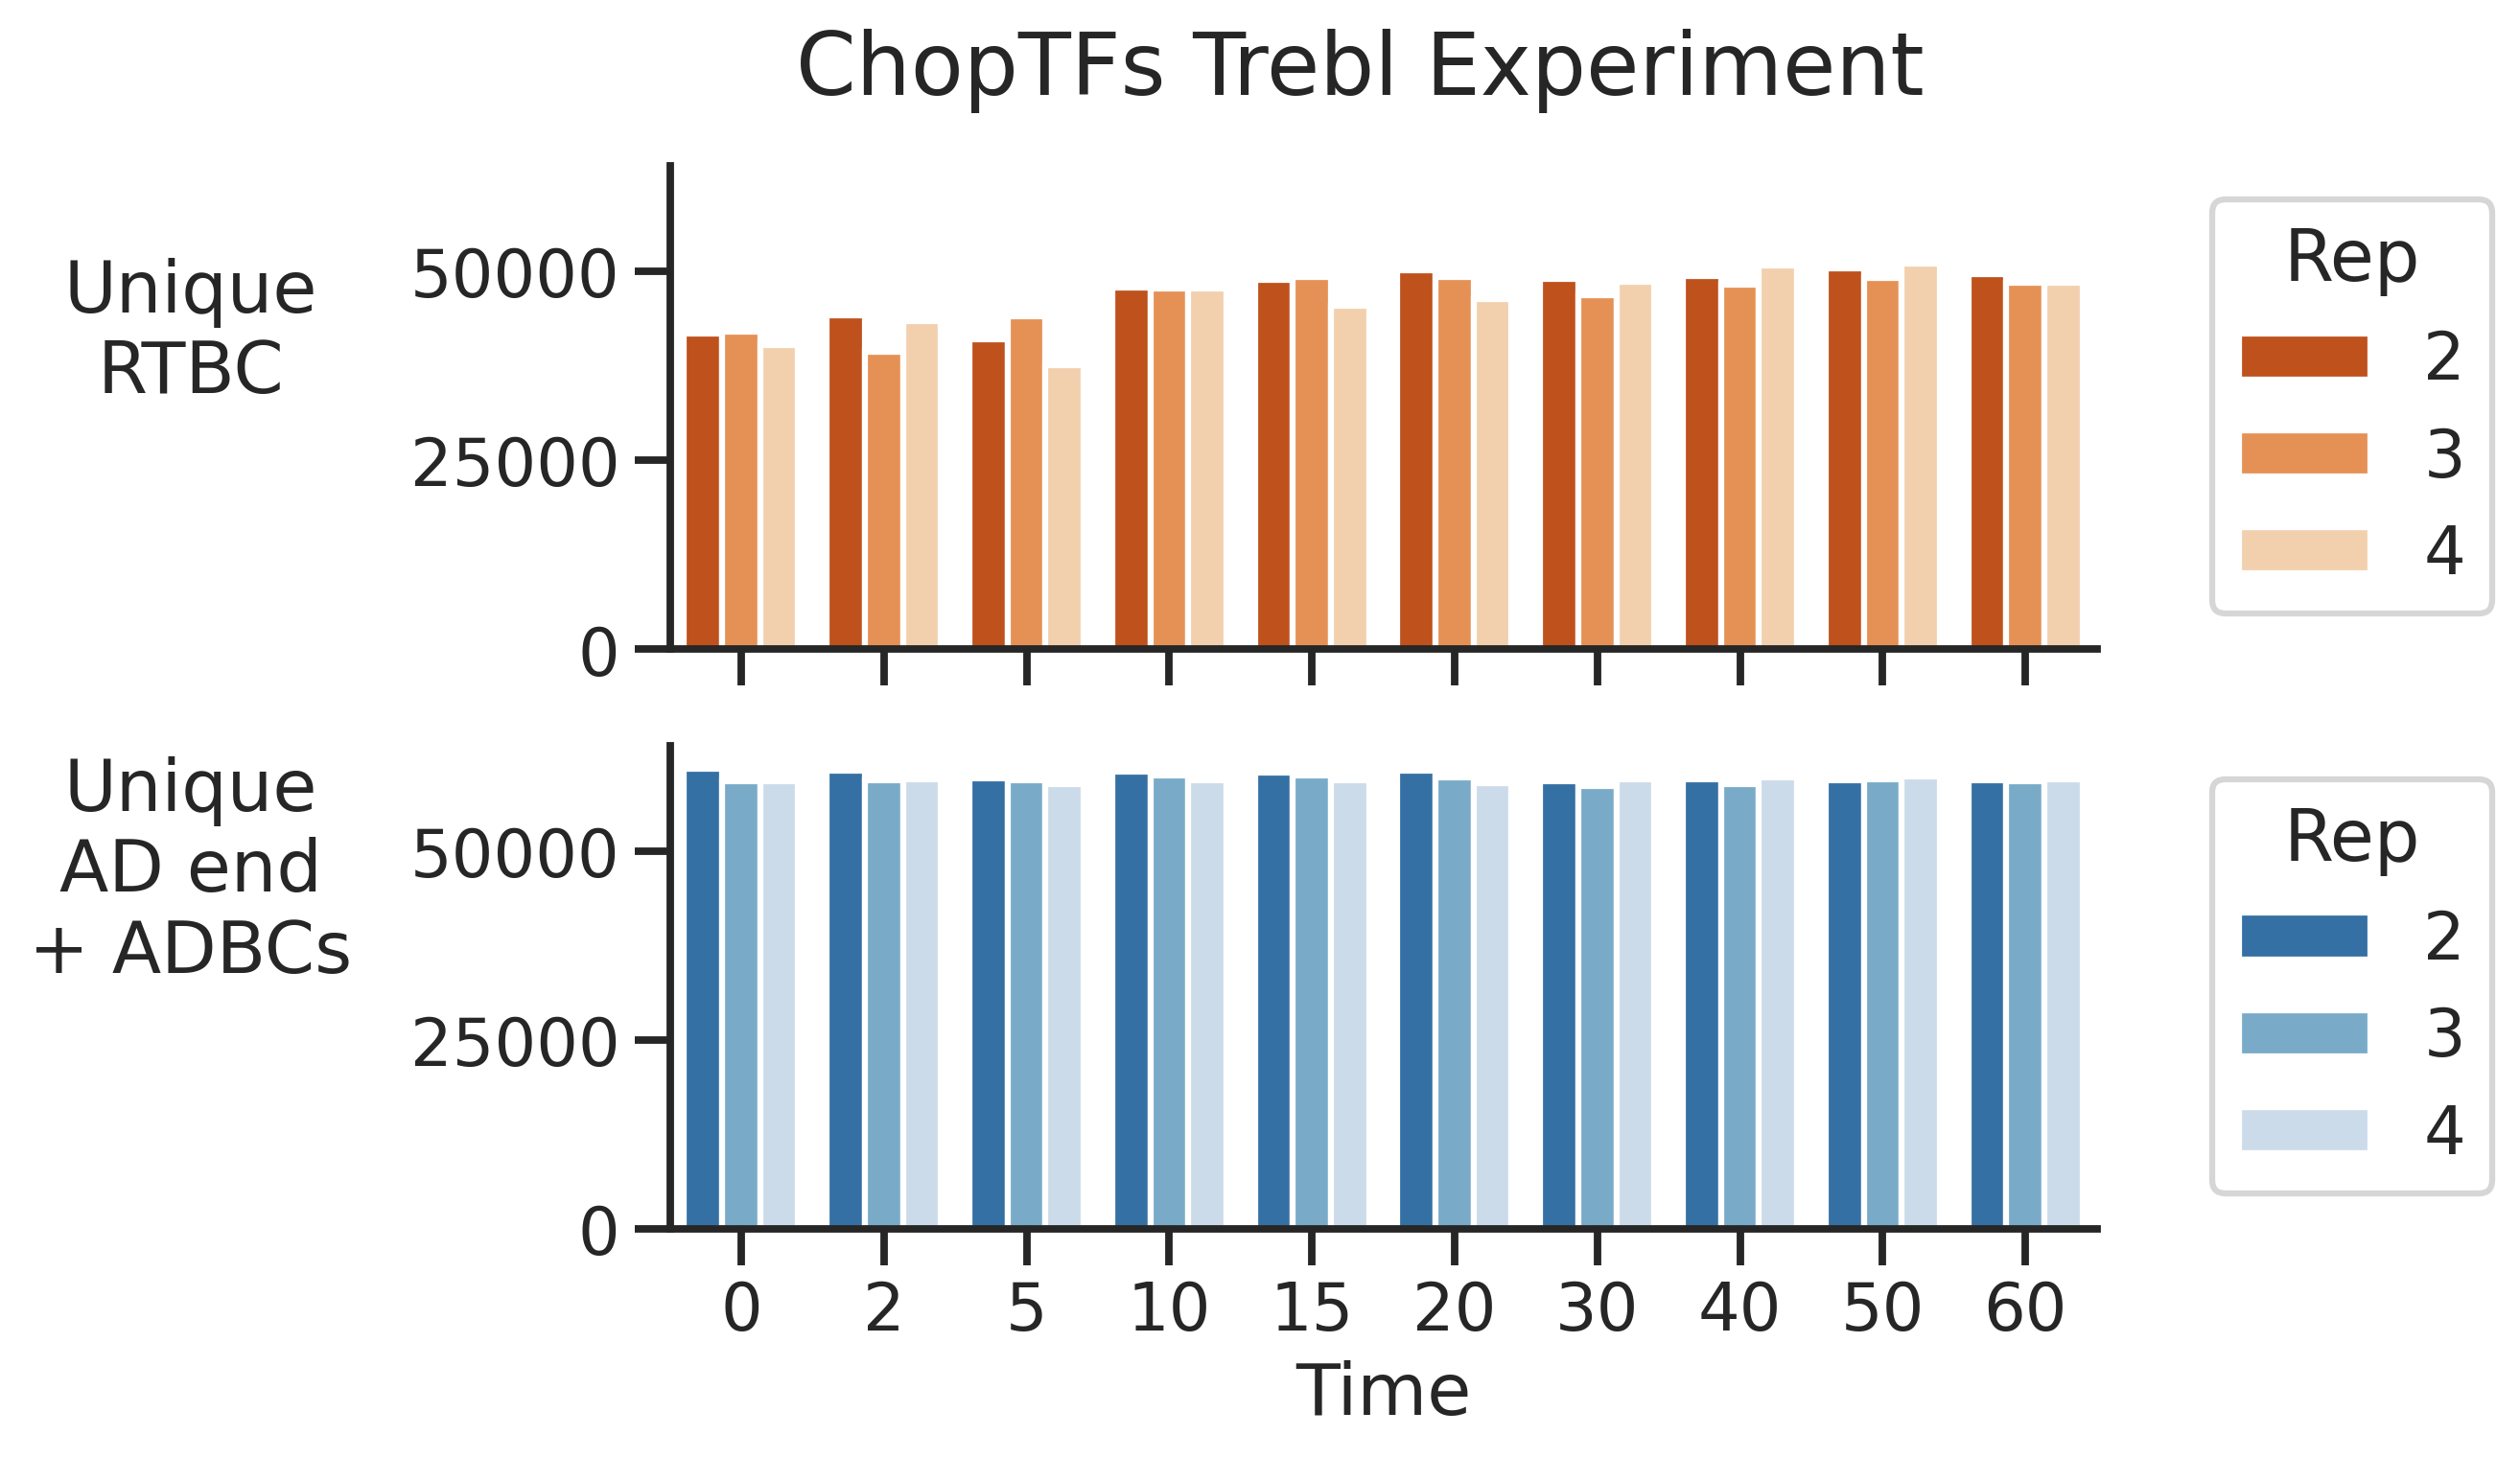

In [24]:
sns.set_context('talk')
sns.set_style('ticks')

fig,axs = plt.subplots(2,1, sharex = True, sharey = True, dpi = 300)
sns.barplot(data = RT_bc_counts, x = "time", y = "RT_BC_count", hue = "rep", ax = axs[0], palette = sns.color_palette("Oranges_r", 3))
sns.barplot(data = AD_bc_counts, x = "time", y = "AD_BC_count", hue = "rep", ax = axs[1], palette = sns.color_palette("Blues_r", 3))

axs[0].legend(loc = 'upper right', bbox_to_anchor = (1.3,1), title = "Rep")
axs[1].legend(loc = 'upper right', bbox_to_anchor = (1.3,1), title = "Rep")

axs[0].set_ylabel("Unique\nRTBC", rotation = 0, labelpad = 55)
axs[1].set_ylabel("Unique\nAD end\n+ ADBCs", rotation = 0, labelpad = 55)

fig.suptitle("ChopTFs Trebl Experiment")
axs[1].set_xlabel("Time")
sns.despine()

In [26]:
len(step1["AD"].unique())

18410